# Basic Task 2

パラメータ値F=8とする。誤差の平均発達率について調べ、0.2時間ステップを1日と定義することの妥当性を確認する。
ヒント）Lorenz (1996)の”error doubling time”の議論をフォローすると良い。データ同化コミュティでは誤差は通常、root mean square error (RMSE)で評価するので、以後RMSEで評価すること。


In [2]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    Lorenz96モデルの微分方程式を定義する関数
    x: 状態変数の配列
    F: 外部からの強制力
    """
    N = len(x)
    dxdt = np.zeros(N)
    for i in range(N):
        dxdt[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F
    return dxdt
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + 0.5 * dt * k1, F)
    k3 = L96(x + 0.5 * dt * k2, F)
    k4 = L96(x + dt * k3, F)
    return x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

In [3]:
# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]

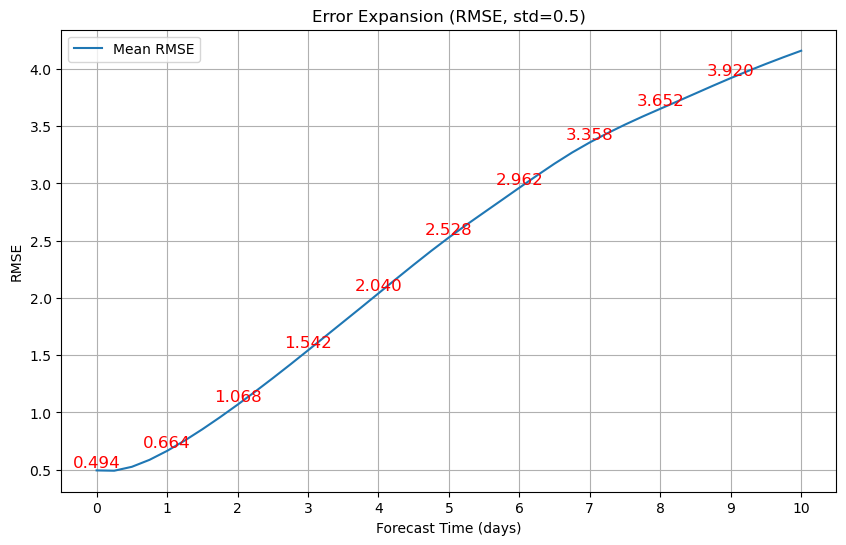

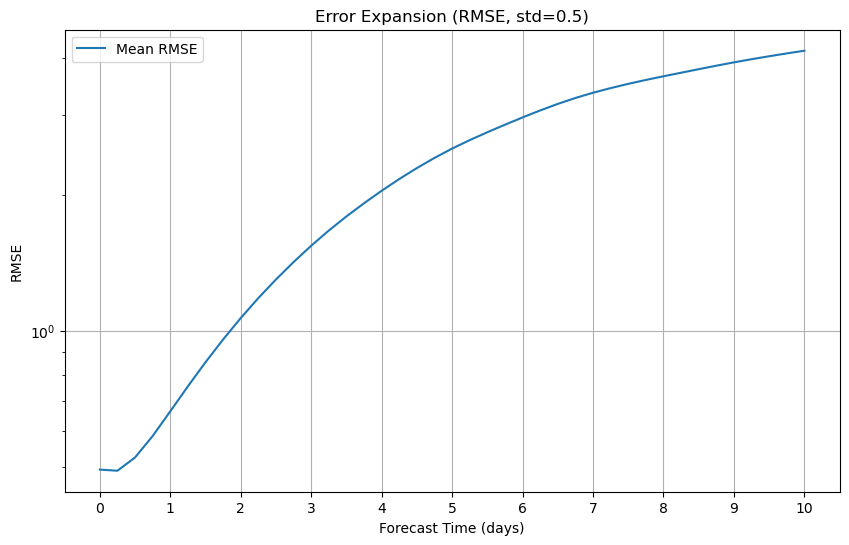

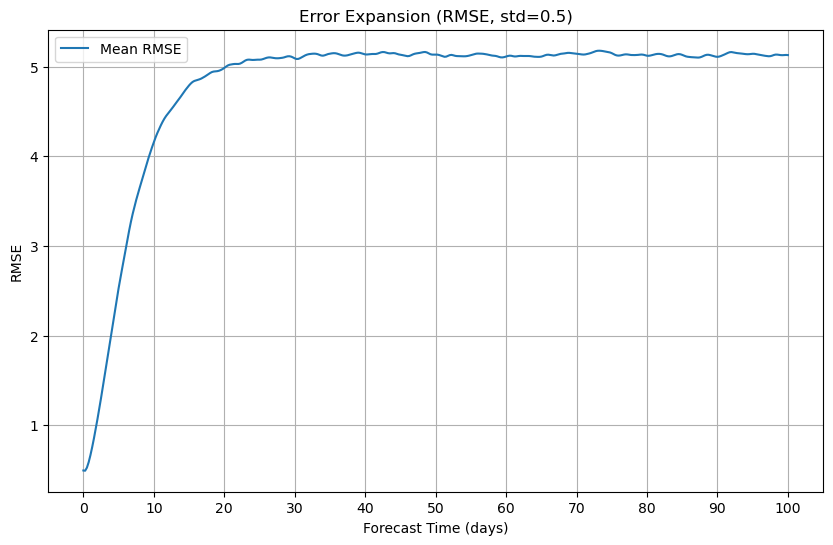

In [18]:
# 状態変数のコンストラクタを定義
state = StateArray(N=40, F=8.0, dt=0.05, method='rk4')

# 3年間分スピンアップする、1日を0.2ステップで計算
# ステップ幅はdtである
spinup_steps = int((3 * 365 / 5) / state.dt)
for _ in range(spinup_steps):
    state.step()
# さらに1000+0.2*10/0.05ステップ計算する
forecast_days = 100
forecast_steps = int(forecast_days*0.2 / state.dt) + 1
total_steps = 1000 + forecast_steps
states = np.zeros((total_steps, state.N))
for i in range(total_steps):
    states[i] = state.x
    state.step()
#　サイズ(40, 1000)のガウシアンノイズを生成
noise = generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0)
std = 0.5 # ノイズに掛ける係数
forecast = np.zeros((1000, forecast_steps, state.N))  # 1000個の予報、各予報はforecast_stepsステップ数、40変数
for i in range(1000):
    forecast_state = StateArray(N=40, F=8.0, dt=0.05, method='rk4')
    forecast_state.x = states[i].copy()  + np.array(noise[i]) * std
    for j in range(forecast_steps):
        forecast[i, j] = forecast_state.x
        forecast_state.step()

# 各予報に対応するstateとのRMSE、予報ステップごとに計算
rmse = np.zeros((1000, forecast_steps))
for i in range(1000):
    for j in range(forecast_steps):
        rmse[i, j] = np.sqrt(np.mean(np.square(forecast[i, j] - states[i + j])))
# 予報ステップごとのRMSEの平均を計算
mean_rmse = np.mean(rmse, axis=0)


# 予報ステップごとのRMSEの平均をプロット
# 最初の10日間を表示
# メモリは1日が0.2ステップなので、5倍して日数に変換
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(np.arange(40+1) * state.dt * 5, mean_rmse[0:41], label='Mean RMSE')
ax1.set_xlabel('Forecast Time (days)')
ax1.set_ylabel('RMSE')
ax1.set_title('Error Expansion (RMSE, std={})'.format(std))
ax1.legend()
ax1.grid()
ax1.set_xticks(np.arange(0, 11, 1))
# Day0, Day1, Day2, Day3の位置にmean_rmseを表示
for i in range(10):
    ax1.text(i, mean_rmse[i*4], '{:.3f}'.format(mean_rmse[i*4]), ha='center', va='bottom', fontsize=12, color='red')
plt.show()

# 最初の100日間を表示(常用対数スケール)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(np.arange(40+1) * state.dt * 5, mean_rmse[0:41], label='Mean RMSE')
ax2.set_xlabel('Forecast Time (days)')
ax2.set_ylabel('RMSE')
ax2.set_yscale('log')
ax2.set_title('Error Expansion (RMSE, std={})'.format(std))
ax2.legend()
ax2.grid()
ax2.set_xticks(np.arange(0, 11, 1))
plt.show()

# 100日間全てを表示
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.plot(np.arange(forecast_steps) * state.dt * 5, mean_rmse, label='Mean RMSE')
ax3.set_xlabel('Forecast Time (days)')
ax3.set_ylabel('RMSE')
ax3.set_title('Error Expansion (RMSE, std={})'.format(std))
ax3.legend()
ax3.grid()
ax3.set_xticks(np.arange(0, 101, 10))
plt.show()
